In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [2]:
tickers = [
    "RELIANCE.NS","TCS.NS","INFY.NS","HDFCBANK.NS","ICICIBANK.NS",
    "ITC.NS","SBIN.NS","LT.NS","BHARTIARTL.NS","KOTAKBANK.NS"
]

end = datetime.today()
start = end - timedelta(days=365*3)

data = yf.download(
    tickers,
    start=start.strftime("%Y-%m-%d"),
    end=end.strftime("%Y-%m-%d"),
    auto_adjust=True
)

print(data.head())

[*********************100%***********************]  10 of 10 completed

Price              Close                                                    \
Ticker     BHARTIARTL.NS HDFCBANK.NS ICICIBANK.NS      INFY.NS      ITC.NS   
Date                                                                         
2023-05-02    775.742554  811.850281   899.822571  1171.584351  366.032166   
2023-05-03    765.041931  814.689209   900.554504  1163.972412  368.360565   
2023-05-04    774.662659  831.361633   899.432312  1168.007568  366.161560   
2023-05-05    772.895569  782.210388   904.555420  1154.755005  369.740326   
2023-05-08    779.227539  791.256226   915.240906  1160.716431  372.068726   

Price                                                                       \
Ticker     KOTAKBANK.NS        LT.NS  RELIANCE.NS     SBIN.NS       TCS.NS   
Date                                                                         
2023-05-02   383.051941  2317.621338  1114.331055  544.100647  2960.785156   
2023-05-03   385.005920  2290.260498  1104.767456  539.560974  

In [3]:
close = data["Close"].copy()
close.columns = list(close.columns)
close.columns.name = None

print(close.head())

            BHARTIARTL.NS  HDFCBANK.NS  ICICIBANK.NS      INFY.NS      ITC.NS  \
Date                                                                            
2023-05-02     775.742554   811.850281    899.822571  1171.584351  366.032166   
2023-05-03     765.041931   814.689209    900.554504  1163.972412  368.360565   
2023-05-04     774.662659   831.361633    899.432312  1168.007568  366.161560   
2023-05-05     772.895569   782.210388    904.555420  1154.755005  369.740326   
2023-05-08     779.227539   791.256226    915.240906  1160.716431  372.068726   

            KOTAKBANK.NS        LT.NS  RELIANCE.NS     SBIN.NS       TCS.NS  
Date                                                                         
2023-05-02    383.051941  2317.621338  1114.331055  544.100647  2960.785156  
2023-05-03    385.005920  2290.260498  1104.767456  539.560974  2924.458252  
2023-05-04    388.325714  2290.843262  1117.503662  548.545715  2961.981201  
2023-05-05    384.557312  2310.866211  111

In [4]:
close = close.ffill().bfill()

print(close.isna().sum())

BHARTIARTL.NS    0
HDFCBANK.NS      0
ICICIBANK.NS     0
INFY.NS          0
ITC.NS           0
KOTAKBANK.NS     0
LT.NS            0
RELIANCE.NS      0
SBIN.NS          0
TCS.NS           0
dtype: int64


In [5]:
returns = close.pct_change(fill_method=None).dropna()

print(returns.head())

            BHARTIARTL.NS  HDFCBANK.NS  ICICIBANK.NS   INFY.NS    ITC.NS  \
Date                                                                       
2023-05-03      -0.013794     0.003497      0.000813 -0.006497  0.006361   
2023-05-04       0.012575     0.020465     -0.001246  0.003467 -0.005970   
2023-05-05      -0.002281    -0.059121      0.005696 -0.011346  0.009774   
2023-05-08       0.008193     0.011564      0.011813  0.005163  0.006297   
2023-05-09      -0.000189     0.000030     -0.003732  0.004030 -0.017731   

            KOTAKBANK.NS     LT.NS  RELIANCE.NS   SBIN.NS    TCS.NS  
Date                                                                 
2023-05-03      0.005101 -0.011806    -0.008582 -0.008343 -0.012269  
2023-05-04      0.008623  0.000254     0.011528  0.016652  0.012831  
2023-05-05     -0.009704  0.008740    -0.002553 -0.006034  0.003105  
2023-05-08      0.015632 -0.005089     0.012348  0.012316  0.006160  
2023-05-09     -0.002323  0.003784     0.003095

In [6]:
metrics = pd.DataFrame(index=close.columns)

metrics["Annual Return %"] = returns.mean() * 252 * 100
metrics["Volatility %"] = returns.std() * np.sqrt(252) * 100

risk_free = 0.065

metrics["Sharpe Ratio"] = (
    (metrics["Annual Return %"]/100 - risk_free) /
    (metrics["Volatility %"]/100)
)

metrics["Total Return %"] = (
    (close.iloc[-1] / close.iloc[0] - 1) * 100
).values

print(metrics.round(2))

               Annual Return %  Volatility %  Sharpe Ratio  Total Return %
BHARTIARTL.NS            32.37         20.44          1.27          143.23
HDFCBANK.NS               0.23         19.72         -0.32           -4.95
ICICIBANK.NS             13.27         18.52          0.37           40.41
INFY.NS                   3.30         24.50         -0.13            0.87
ITC.NS                   -3.38         18.64         -0.53          -13.97
KOTAKBANK.NS              2.45         21.98         -0.18            0.06
LT.NS                    21.96         25.43          0.61           73.19
RELIANCE.NS              10.66         20.72          0.20           28.40
SBIN.NS                  25.84         23.78          0.81           96.37
TCS.NS                   -3.89         21.12         -0.49          -16.44


In [7]:
metrics.to_csv("metrics.csv", index=True)

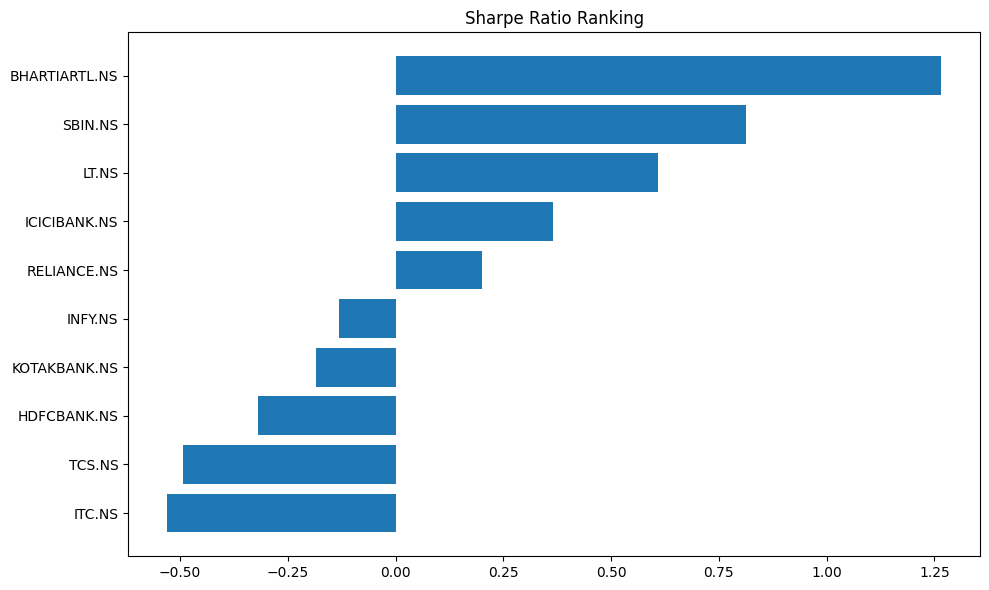

In [8]:
top = metrics["Sharpe Ratio"].sort_values()

plt.figure(figsize=(10,6))
plt.barh(top.index, top.values)
plt.title("Sharpe Ratio Ranking")
plt.tight_layout()
plt.show()

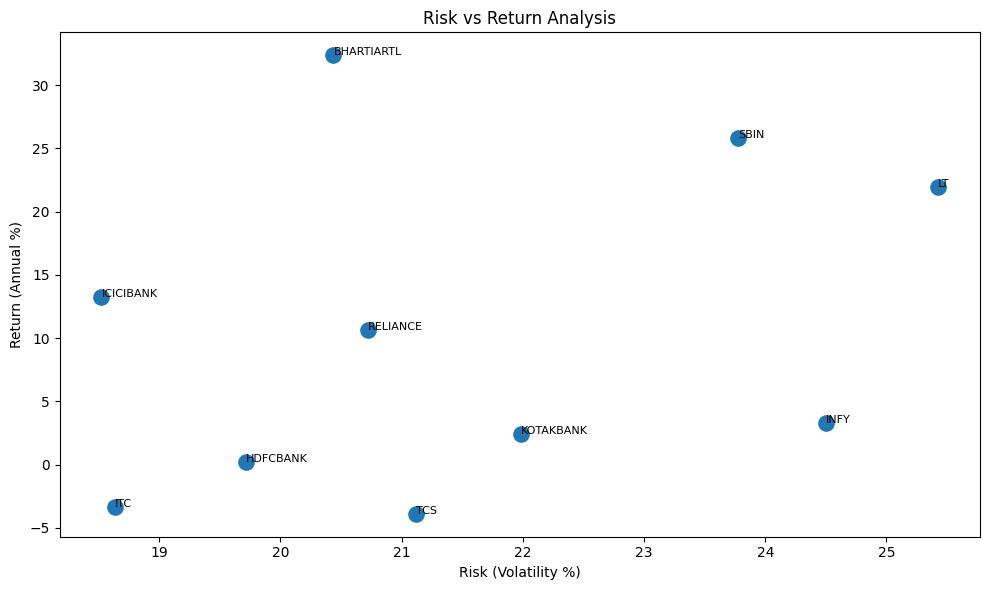

In [10]:
plt.figure(figsize=(10,6))

plt.scatter(
    metrics["Volatility %"],
    metrics["Annual Return %"],
    s=120
)

for stock in metrics.index:
    plt.annotate(
        stock.replace(".NS",""),
        (
            metrics.loc[stock,"Volatility %"],
            metrics.loc[stock,"Annual Return %"]
        ),
        fontsize=8
    )

plt.xlabel("Risk (Volatility %)")
plt.ylabel("Return (Annual %)")
plt.title("Risk vs Return Analysis")
plt.tight_layout()
plt.show()

In [ ]:
Total Return Ranking Chart

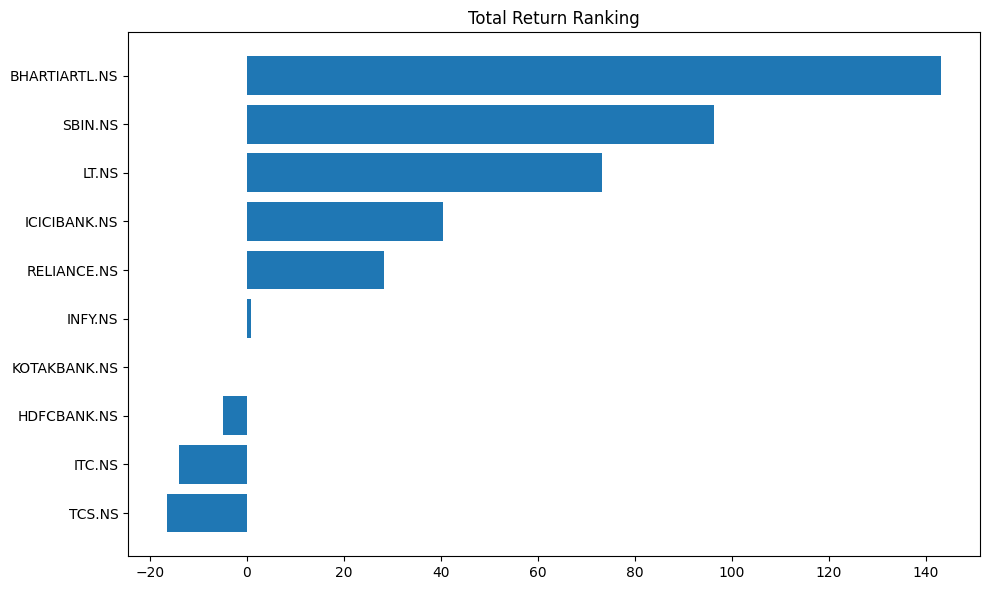

In [11]:
top_return = metrics["Total Return %"].sort_values()

plt.figure(figsize=(10,6))
plt.barh(top_return.index, top_return.values)
plt.title("Total Return Ranking")
plt.tight_layout()
plt.show()

In [ ]:
metrics.to_csv("metrics.csv")

In [ ]:
sector_map = {
    "RELIANCE.NS":"Energy",
    "TCS.NS":"IT",
    "INFY.NS":"IT",
    "HDFCBANK.NS":"Banking",
    "ICICIBANK.NS":"Banking",
    "ITC.NS":"FMCG",
    "SBIN.NS":"Banking",
    "LT.NS":"Infrastructure",
    "BHARTIARTL.NS":"Telecom",
    "KOTAKBANK.NS":"Banking"
}

metrics["Sector"] = metrics.index.map(sector_map)
metrics

In [ ]:
sector_avg = metrics.groupby("Sector")["Annual Return %"].mean()

sector_avg.plot(kind="bar", figsize=(10,6), title="Sector Average Returns")
plt.tight_layout()
plt.show()

In [ ]:
metrics.to_csv("metrics.csv")